## 学习率优化  
学习率( learning rate )是神经网络训练中一个重要的超参数，用于控制模型更新参数的步长大小，它决定了每次迭代中模型参数更新的幅度。学习率的选择对于训练的结果具有重要影响，学习率过高会导致模型震荡不收敛甚至发散，无法有效优化目标函数；而学习率过低则会导致收敛速度缓慢，需要更多的迭代才能达到较好的效果。本节首先介绍学习率如何影响模型训练，并通过修改学习率观察不同学习率对模型性能的影响。

## 1.学习率简介  
在神经网络训练中，我们通过最小化损失函数来优化模型的参数。梯度下降是一种常用的优化算法，它通过计算损失函数对于每个参数的导数来指导参数的更新，而学习率就是梯度下降算法中的一个重要的调节参数。  

为了了解学习率对模型训练的影响，我们尝试拟合以下简单方程：  
$$
y = 3 \times x
$$

1. 定义输入和输出数据集：  

In [1]:
x = [[1],[2],[3],[4]]
y = [[3],[6],[9],[12]] 

2. 定义 feed_forward() 函数，此处使用的网络并不包含隐藏层：

$$
y = w \times x + b
$$

在以上函数中，我们尝试估计参数 w 和 b ：

In [2]:
from copy import deepcopy
import numpy as np
def feed_forward(inputs, outputs, weights):
    out = np.dot(inputs, weights[0]) + weights[1]
    mean_squared_error = np.mean(np.square(out - outputs))
    return mean_squared_error

3. 定义 update_weights() 函数利用梯度下降更新网络权重：

In [6]:
def update_weights(inputs, outputs, weights, lr):
    original_weights = deepcopy(weights)
    org_loss = feed_forward(inputs, outputs, original_weights)
    updated_weights = deepcopy(weights)
    for i, layer in enumerate(weights):
         for index, weight in np.ndenumerate(layer):
              temp_weights = deepcopy(original_weights)
              temp_weights[i][index] += 0.0001
              _loss_plus = feed_forward(inputs, outputs, temp_weights)
              grad = (_loss_plus - org_loss) / 0.0001
              updated_weights[i][index] -= lr * grad
    return updated_weights

4. 将权重和偏差值初始化为随机值：

In [4]:
W = [np.array([[0]], dtype=np.float32), np.array([0], dtype=np.float32)]

权重和偏差值随机初始化为0，输入权重值的形状为1 x 1，因为输入中每个数据点的形状为1 x 1，偏置值的形状为1 x 1(输出中只有一个节点，每个输出只有一个值)。

5. 将学习率设为0.01执行update_weights()函数，循环迭代1000次，并检查权重值（W）随时间的变化：

In [7]:
weight_value = []
for epx in range(1000):
    W = update_weights(x, y, W, 0.01)
    weight_value.append(W[0][0][0])

6. 绘制每个epoch结束时的权重参数值：

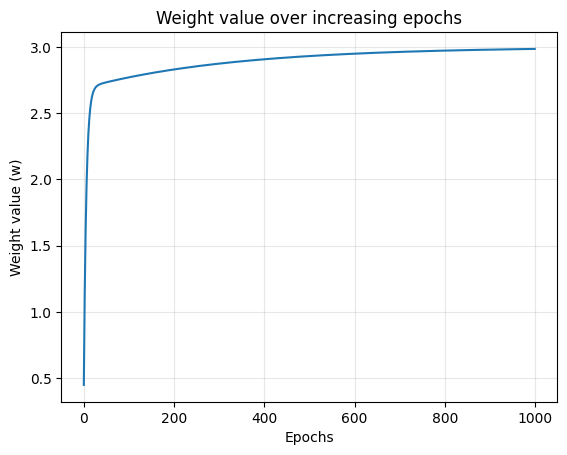

In [ ]:
plt.plot(weight_value)
plt.title('Weight value over increasing epochs')
plt.xlabel('Epochs')
plt.ylabel('Weight value (w)')
plt.grid(alpha=0.3) 
plt.show()


可以看到，在上图中，权重值逐渐增加，最终在 3 附近达到稳定。

为了了解学习率对权重更新的影响， 我们测试当学习率为 0.1和1时，权重值随时间的变化，下图显示了使用不同学习率时，权重的变化情况：

- 学习率0.1

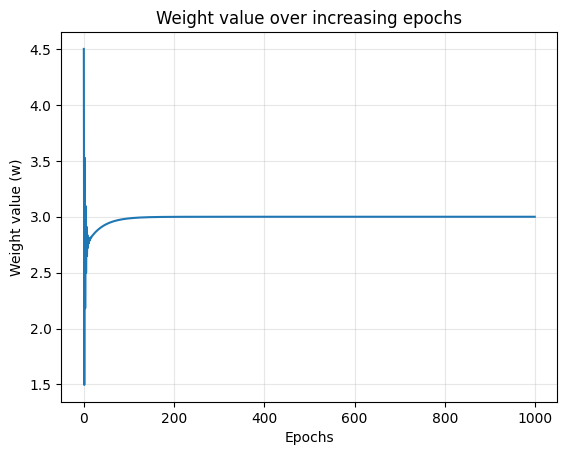

In [10]:
# 导入所需库
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

# 定义训练数据
x = [[1], [2], [3], [4]]
y = [[3], [6], [9], [12]]

# 转换为numpy数组（方便矩阵运算）
x = np.array(x, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# 前向传播函数：计算预测值和均方误差
def feed_forward(inputs, outputs, weights):
    # 线性预测：y = w*x + b
    out = np.dot(inputs, weights[0]) + weights[1]
    # 计算均方误差（MSE）
    mean_squared_error = np.mean(np.square(out - outputs))
    return mean_squared_error

# 权重更新函数：使用数值梯度下降更新权重
def update_weights(inputs, outputs, weights, lr):
    # 保存原始权重和对应的损失
    original_weights = deepcopy(weights)
    org_loss = feed_forward(inputs, outputs, original_weights)
    updated_weights = deepcopy(weights)
    
    # 遍历每一层权重（这里是[w, b]两层）
    for i, layer in enumerate(weights): 
        # 遍历当前层的每个权重参数
        for index, weight in np.ndenumerate(layer):
            # 临时权重：给当前参数加一个微小值（0.0001）
            temp_weights = deepcopy(original_weights)  
            temp_weights[i][index] += 0.0001
            # 计算微小值后的损失
            _loss_plus = feed_forward(inputs, outputs, temp_weights)
            # 计算数值梯度：(损失变化量) / (参数变化量)
            grad = (_loss_plus - org_loss) / 0.0001
            # 梯度下降更新权重：权重 = 权重 - 学习率*梯度
            updated_weights[i][index] -= lr * grad
    return updated_weights

# 初始化权重：W[0]是w（斜率），W[1]是b（截距）
W = [np.array([[0]], dtype=np.float32), np.array([0], dtype=np.float32)]

# 记录训练过程中的权重变化
weight_value = []

# 训练循环（1000个epoch）
for epoch in range(1000):  
    # 更新权重
    W = update_weights(x, y, W, 0.1)
    # 记录当前的w值（斜率）
    weight_value.append(W[0][0][0])

# 可视化权重变化
plt.plot(weight_value)
plt.title('Weight value over increasing epochs')
plt.xlabel('Epochs')
plt.ylabel('Weight value (w)')
plt.grid(alpha=0.3)  # 增加网格，更易观察
plt.show()


- 学习率1

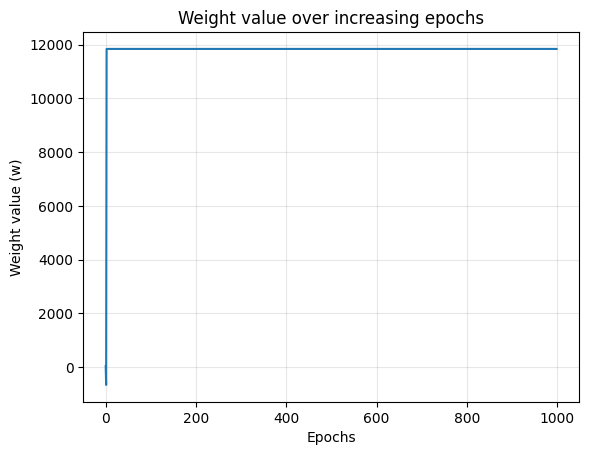

In [11]:
# 导入所需库
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

# 定义训练数据
x = [[1], [2], [3], [4]]
y = [[3], [6], [9], [12]]

# 转换为numpy数组（方便矩阵运算）
x = np.array(x, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# 前向传播函数：计算预测值和均方误差
def feed_forward(inputs, outputs, weights):
    # 线性预测：y = w*x + b
    out = np.dot(inputs, weights[0]) + weights[1]
    # 计算均方误差（MSE）
    mean_squared_error = np.mean(np.square(out - outputs))
    return mean_squared_error

# 权重更新函数：使用数值梯度下降更新权重
def update_weights(inputs, outputs, weights, lr):
    # 保存原始权重和对应的损失
    original_weights = deepcopy(weights)
    org_loss = feed_forward(inputs, outputs, original_weights)
    updated_weights = deepcopy(weights)
    
    # 遍历每一层权重（这里是[w, b]两层）
    for i, layer in enumerate(weights): 
        # 遍历当前层的每个权重参数
        for index, weight in np.ndenumerate(layer):
            # 临时权重：给当前参数加一个微小值（0.0001）
            temp_weights = deepcopy(original_weights)  
            temp_weights[i][index] += 0.0001
            # 计算微小值后的损失
            _loss_plus = feed_forward(inputs, outputs, temp_weights)
            # 计算数值梯度：(损失变化量) / (参数变化量)
            grad = (_loss_plus - org_loss) / 0.0001
            # 梯度下降更新权重：权重 = 权重 - 学习率*梯度
            updated_weights[i][index] -= lr * grad
    return updated_weights

# 初始化权重：W[0]是w（斜率），W[1]是b（截距）
W = [np.array([[0]], dtype=np.float32), np.array([0], dtype=np.float32)]

# 记录训练过程中的权重变化
weight_value = []

# 训练循环（1000个epoch）
for epoch in range(1000):  
    # 更新权重
    W = update_weights(x, y, W, 1)
    # 记录当前的w值（斜率）
    weight_value.append(W[0][0][0])

# 可视化权重变化
plt.plot(weight_value)
plt.title('Weight value over increasing epochs')
plt.xlabel('Epochs')
plt.ylabel('Weight value (w)')
plt.grid(alpha=0.3)  # 增加网格，更易观察
plt.show()

可以看到，当学习率非常小时( 0.01 )时，权重值缓慢向最优值移动(需要更多的 epoch)；而在学习率较高( 0.1 )时，权重值最初变化较为剧烈，然后迅速得到最优值(需要较少的 epoch)；而当学习率过高( 1 )时，权重值无法达到最优值。

学习率低时权重值没有大幅变化的原因是我们将权重更新量限制为 梯度 x 学习率，本质上是由于学习率较小导致更新量较小；当学习率过高时，权重更新量相应较高，损失的变化非常小（收敛不了），以至于权重无法达到最优值。

## 2. 梯度值、学习率和权重之间的相互作用  
为了更深入地了解梯度值、学习率和权重之间的相互作用，我们只运行 10 个 epoch 的 update_weights() 函数，并打印以下值以了解它们如何随 epoch 变化：  
- 每个epoch开始时的权重值
- 权重更新前的损失
- 少量更新权重后的损失
- 梯度值
修改update_weights()函数以打印以上值：



In [12]:
def update_weights(inputs, outputs, weights, lr):
    original_weights = deepcopy(weights)
    org_loss = feed_forward(inputs, outputs, original_weights)
    updated_weights = deepcopy(weights)
    for i, layer in enumerate(original_weights):
        for index, weight in np.ndenumerate(layer):
            temp_weights = deepcopy(weights)
            temp_weights[i][index] += 0.0001
            _loss_plus = feed_forward(inputs, outputs, temp_weights)
            grad = (_loss_plus - org_loss)/(0.0001)
            updated_weights[i][index] -= grad*lr
            if(i % 2 == 0):
                print('weight value:', np.round(original_weights[i][index],2),
                      'original loss:', np.round(org_loss,2),
                      'loss_plus:', np.round(_loss_plus,2),
                      'gradient:', np.round(grad,2),
                      'updated_weights:', np.round(updated_weights[i][index],2))
    return updated_weights

在以上代码中，打印原始权重值( original_weights[i][index])、损失( org_loss)、权重更新后损失值( _loss_plus)、梯度( grad )以及更新后的权重值( updated_weights)。使用不同的学习率，观察以上各值如何随着 epoch 变化。

- 学习率0.01时

weight value: 0.0 original loss: 67.5 loss_plus: 67.5 gradient: -45.01 updated_weights: 0.45
weight value: 0.45 original loss: 46.88 loss_plus: 46.88 gradient: -37.5 updated_weights: 0.83
weight value: 0.83 original loss: 32.57 loss_plus: 32.57 gradient: -31.28 updated_weights: 1.14
weight value: 1.14 original loss: 22.63 loss_plus: 22.63 gradient: -26.04 updated_weights: 1.4
weight value: 1.4 original loss: 15.75 loss_plus: 15.74 gradient: -21.71 updated_weights: 1.62
weight value: 1.62 original loss: 10.97 loss_plus: 10.97 gradient: -18.1 updated_weights: 1.8
weight value: 1.8 original loss: 7.65 loss_plus: 7.65 gradient: -15.09 updated_weights: 1.95
weight value: 1.95 original loss: 5.35 loss_plus: 5.35 gradient: -12.6 updated_weights: 2.07
weight value: 2.07 original loss: 3.75 loss_plus: 3.75 gradient: -10.48 updated_weights: 2.18
weight value: 2.18 original loss: 2.64 loss_plus: 2.64 gradient: -8.75 updated_weights: 2.27
[array([[2.2655725]], dtype=float32), array([[0.74050426]],

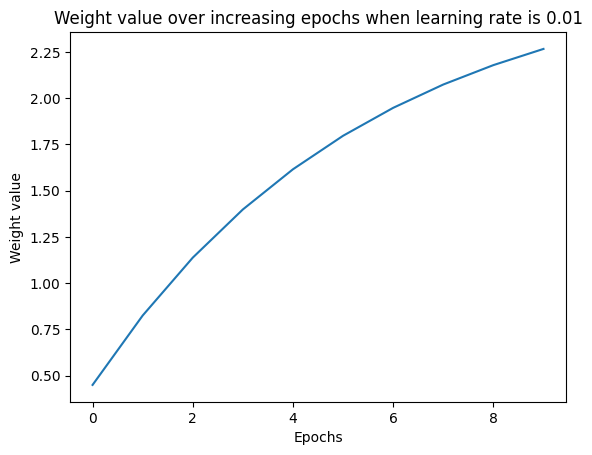

In [13]:
W = [np.array([[0]], dtype=np.float32), np.array([[0]], dtype=np.float32)]
weight_value = []
for epoch in range(10):
    W = update_weights(x, y, W, 0.01)
    weight_value.append(W[0][0][0])
print(W)
import matplotlib.pyplot as plt
plt.plot(weight_value[:100])
plt.title('Weight value over increasing epochs when learning rate is 0.01')
plt.xlabel('Epochs')
plt.ylabel('Weight value')
plt.show()

可以看到，当学习率为 0.01 时，损失值缓慢下降，权重值也缓慢向最优值移动。

- 学习率为0.1时

weight value: 0.0 original loss: 67.5 loss_plus: 67.5 gradient: -45.01 updated_weights: 4.5
weight value: 4.5 original loss: 30.37 loss_plus: 30.37 gradient: 30.06 updated_weights: 1.5
weight value: 1.5 original loss: 13.81 loss_plus: 13.81 gradient: -20.32 updated_weights: 3.53
weight value: 3.53 original loss: 6.25 loss_plus: 6.25 gradient: 13.46 updated_weights: 2.18
weight value: 2.18 original loss: 2.86 loss_plus: 2.86 gradient: -9.14 updated_weights: 3.1
weight value: 3.1 original loss: 1.33 loss_plus: 1.33 gradient: 5.98 updated_weights: 2.5
weight value: 2.5 original loss: 0.65 loss_plus: 0.65 gradient: -4.13 updated_weights: 2.91
weight value: 2.91 original loss: 0.34 loss_plus: 0.34 gradient: 2.63 updated_weights: 2.65
weight value: 2.65 original loss: 0.2 loss_plus: 0.2 gradient: -1.88 updated_weights: 2.84
weight value: 2.84 original loss: 0.13 loss_plus: 0.13 gradient: 1.14 updated_weights: 2.72
[array([[2.7220845]], dtype=float32), array([[0.6583333]], dtype=float32)]


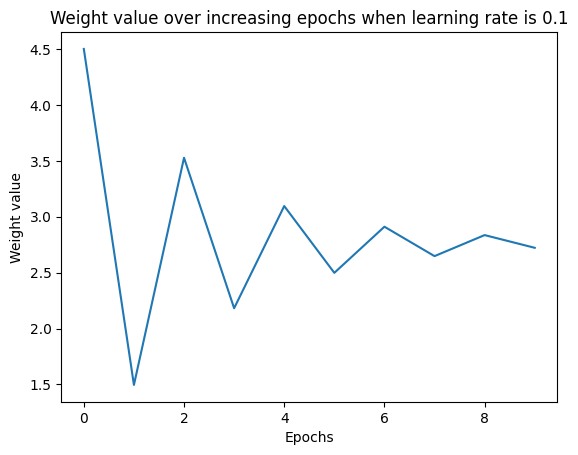

In [14]:
W = [np.array([[0]], dtype=np.float32), np.array([[0]], dtype=np.float32)]
weight_value = []
for epoch in range(10):
    W = update_weights(x, y, W, 0.1)
    weight_value.append(W[0][0][0])
print(W)
import matplotlib.pyplot as plt
plt.plot(weight_value[:100])
plt.title('Weight value over increasing epochs when learning rate is 0.1')
plt.xlabel('Epochs')
plt.ylabel('Weight value')
plt.show()

对比学习率分别为 0.01 和 0.1 的结果，主要区别如下：与学习率为 0.1 时相比，学习率为 0.01 时，权重的更新要慢得多，更新速度较慢的原因是学习率较低，因为权重是通过梯度乘以学习率来更新的。​
除了权重更新的幅度，我们还要注意权重更新的方向：当权重值小于最优值时梯度为负，当权重值大于最优值时梯度为正，从而保证了网络在正确的方向上更新权重值。

- 学习率为1时：

weight value: 0.0 original loss: 67.5 loss_plus: 67.5 gradient: -45.01 updated_weights: 45.01
weight value: 45.01 original loss: 16603.33 loss_plus: 16603.4 gradient: 703.12 updated_weights: -658.11
weight value: -658.11 original loss: 4124984.0 loss_plus: 4124982.8 gradient: -12500.0 updated_weights: 11841.89
weight value: 11841.89 original loss: 1037107000.0 loss_plus: 1037107000.0 gradient: 0.0 updated_weights: 11841.89
weight value: 11841.89 original loss: 1037107000.0 loss_plus: 1037107000.0 gradient: 0.0 updated_weights: 11841.89
weight value: 11841.89 original loss: 1037107000.0 loss_plus: 1037107000.0 gradient: 0.0 updated_weights: 11841.89
weight value: 11841.89 original loss: 1037107000.0 loss_plus: 1037107000.0 gradient: 0.0 updated_weights: 11841.89
weight value: 11841.89 original loss: 1037107000.0 loss_plus: 1037107000.0 gradient: 0.0 updated_weights: 11841.89
weight value: 11841.89 original loss: 1037107000.0 loss_plus: 1037107000.0 gradient: 0.0 updated_weights: 11841.8

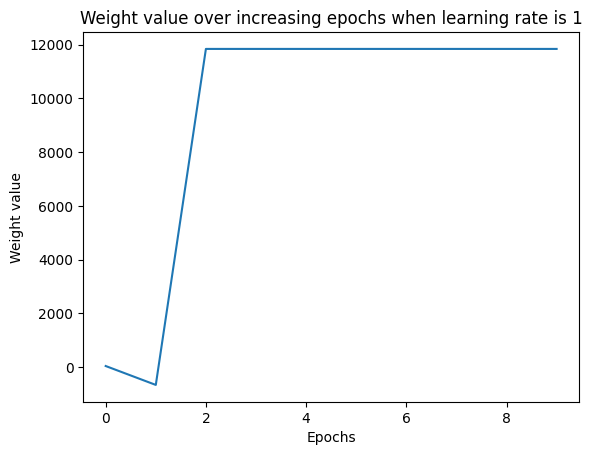

In [15]:
W = [np.array([[0]], dtype=np.float32), np.array([[0]], dtype=np.float32)]
weight_value = []
for epoch in range(10):
    W = update_weights(x, y, W, 1)
    weight_value.append(W[0][0][0])
print(W)
import matplotlib.pyplot as plt
plt.plot(weight_value[:100])
plt.title('Weight value over increasing epochs when learning rate is 1')
plt.xlabel('Epochs')
plt.ylabel('Weight value')
plt.show()

从上图中可以看出，权重与最优值间的偏离较大，除此之外，权重值更新幅度较大，因此权重值的微小变化几乎不会影响梯度的变化，权重并不能收敛于最优值。

一般来说，学习率越低越好。这样，模型能够缓慢学习，并将权重调整为最佳值，学习率参数值通常设置在 0.0001 和 0.01 之间。

## 3.学习率优化实战  
我们已经了解到学习率在获得最佳权重方面起着关键作用。当学习率较小时，权重会平滑的向最优值移动，而当学习率较大时，权重会在非最优值处振荡(陷于局部最优值)。为了理解不同学习率的影响，我们将使用 Fashion MNIST 进行以下实验：​

• 在缩放后的数据集上使用较高学习率 (0.1)​  
• 在缩放后的数据集上使用较低学习率 (0.00001)​  
• 在未缩放的数据集上使用较低学习率 (0.001)​  
• 在未缩放的数据集上使用较高学习率 (0.1)    



### 3.1 学习率对缩放后的数据集的影响  
在本节中，我们将使用不同学习率对比模型在训练和验证数据集上的准确率。

#### 3.1.1 较高学习率  
本节中，我们使用 Adam 优化器，训练过程中唯一的变化是定义 get_model() 函数时，修改优化器中的学习率，将学习率( lr )修改为 0.1。除了对 get_model() 函数进行的修改之外，其他代码都与神经网络训练一节中完全相同。修改优化器，使其学习率为 0.1 ( lr=1e-1)：

In [18]:
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=0.1)
    return model, loss_fn, optimizer

Epoch 1/10:
Train Loss: 4.0308, Train Acc: 59.62%
Val Loss: 1.7099, Val Acc: 58.03%
--------------------------------------------------
Epoch 2/10:
Train Loss: 1.6144, Train Acc: 45.32%
Val Loss: 1.7772, Val Acc: 36.26%
--------------------------------------------------
Epoch 3/10:
Train Loss: 1.9134, Train Acc: 30.65%
Val Loss: 1.8377, Val Acc: 29.08%
--------------------------------------------------
Epoch 4/10:
Train Loss: 2.2335, Train Acc: 17.31%
Val Loss: 2.1521, Val Acc: 18.45%
--------------------------------------------------
Epoch 5/10:
Train Loss: 2.2691, Train Acc: 14.03%
Val Loss: 2.1712, Val Acc: 14.81%
--------------------------------------------------
Epoch 6/10:
Train Loss: 2.2869, Train Acc: 11.66%
Val Loss: 2.2879, Val Acc: 11.46%
--------------------------------------------------
Epoch 7/10:
Train Loss: 2.2848, Train Acc: 12.01%
Val Loss: 2.2815, Val Acc: 11.12%
--------------------------------------------------
Epoch 8/10:
Train Loss: 2.2728, Train Acc: 12.70%
Val L

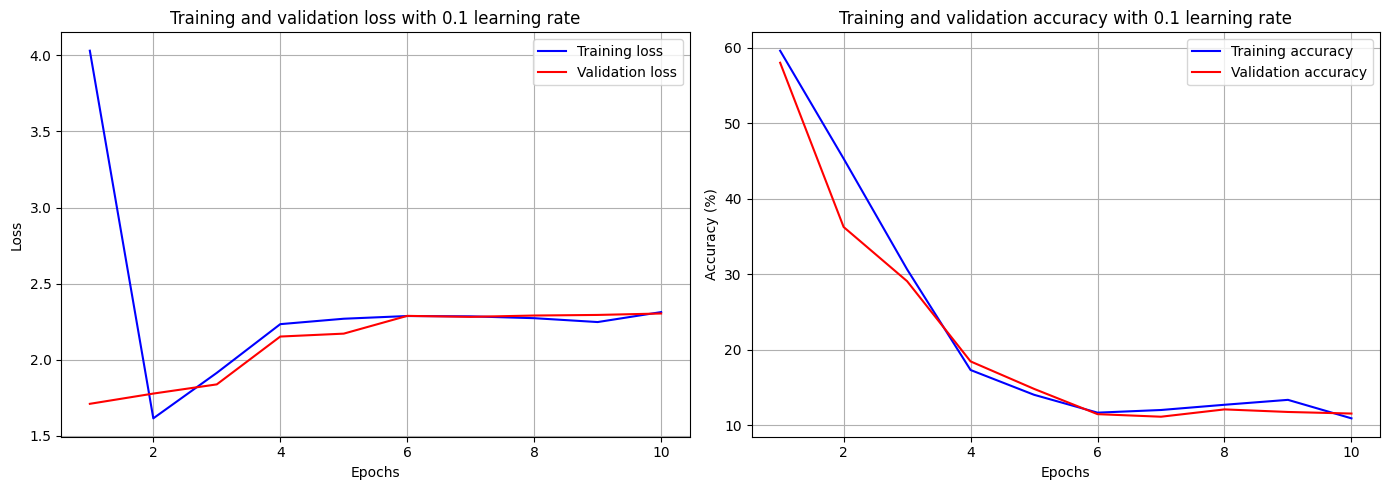

In [24]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 设置设备
device = "cpu"

# 定义模型
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-1)
    return model, loss_fn, optimizer

# 准备数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 训练参数
epochs = 10
model, loss_fn, optimizer = get_model()

# 记录指标
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# 训练循环
for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.view(-1, 28 * 28).to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        train_correct += pred.eq(target.view_as(pred)).sum().item()
        train_total += target.size(0)
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data = data.view(-1, 28 * 28).to(device)
            target = target.to(device)
            
            output = model(data)
            loss = loss_fn(output, target)
            
            val_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
            val_total += target.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
    print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    print('-' * 50)

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失图
ax1.plot(range(1, epochs+1), train_losses, 'b-', label='Training loss')
ax1.plot(range(1, epochs+1), val_losses, 'r-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss with 0.1 learning rate')
ax1.legend()
ax1.grid(True)

# 准确率图
ax2.plot(range(1, epochs+1), train_accuracies, 'b-', label='Training accuracy')
ax2.plot(range(1, epochs+1), val_accuracies, 'r-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and validation accuracy with 0.1 learning rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#### 3.1.2 中等学习率  
通过修改 get_model() 函数并从头开始重新训练模型，将优化器的学习修改为 0.001：

Epoch 1/10:
Train Loss: 0.3159, Train Acc: 91.60%
Val Loss: 0.2713, Val Acc: 92.37%
--------------------------------------------------
Epoch 2/10:
Train Loss: 0.2172, Train Acc: 94.42%
Val Loss: 0.1784, Val Acc: 95.29%
--------------------------------------------------
Epoch 3/10:
Train Loss: 0.1861, Train Acc: 95.18%
Val Loss: 0.2429, Val Acc: 94.30%
--------------------------------------------------
Epoch 4/10:
Train Loss: 0.1811, Train Acc: 95.43%
Val Loss: 0.2212, Val Acc: 95.32%
--------------------------------------------------
Epoch 5/10:
Train Loss: 0.1689, Train Acc: 95.81%
Val Loss: 0.3631, Val Acc: 92.87%
--------------------------------------------------
Epoch 6/10:
Train Loss: 0.1746, Train Acc: 95.68%
Val Loss: 0.2414, Val Acc: 94.95%
--------------------------------------------------
Epoch 7/10:
Train Loss: 0.1634, Train Acc: 95.98%
Val Loss: 0.2456, Val Acc: 95.82%
--------------------------------------------------
Epoch 8/10:
Train Loss: 0.1555, Train Acc: 96.19%
Val L

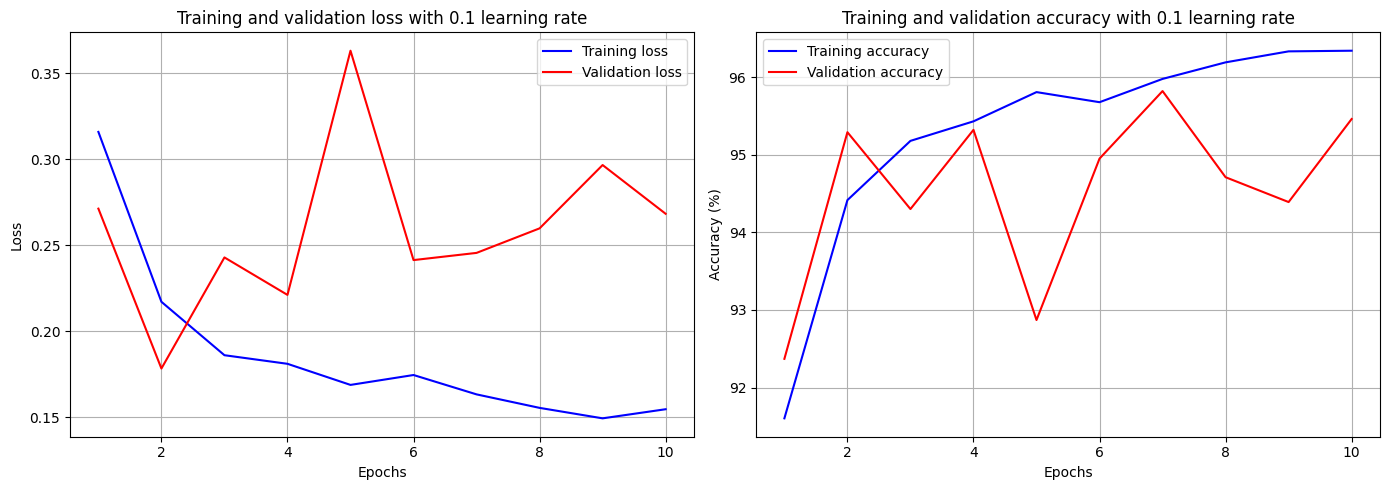

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 设置设备
device = "cpu"

# 定义模型
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

# 准备数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 训练参数
epochs = 10
model, loss_fn, optimizer = get_model()

# 记录指标
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# 训练循环
for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.view(-1, 28 * 28).to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        train_correct += pred.eq(target.view_as(pred)).sum().item()
        train_total += target.size(0)
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data = data.view(-1, 28 * 28).to(device)
            target = target.to(device)
            
            output = model(data)
            loss = loss_fn(output, target)
            
            val_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
            val_total += target.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
    print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    print('-' * 50)

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失图
ax1.plot(range(1, epochs+1), train_losses, 'b-', label='Training loss')
ax1.plot(range(1, epochs+1), val_losses, 'r-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss with 0.1 learning rate')
ax1.legend()
ax1.grid(True)

# 准确率图
ax2.plot(range(1, epochs+1), train_accuracies, 'b-', label='Training accuracy')
ax2.plot(range(1, epochs+1), val_accuracies, 'r-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and validation accuracy with 0.1 learning rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

从以上输出结果可以看出，当学习率从 0.1 降低到 0.001 时，模型性能有了大幅提升。

#### 3.1.3 较低学习率  
通过修改 get_model() 函数并从头开始重新训练模型，将优化器的学习率修改为 0.00001，并运行模型更多的 epoch (100)：

Epoch 1/100:
Train Loss: 1.1003, Train Acc: 76.70%
Val Loss: 0.5391, Val Acc: 88.25%
--------------------------------------------------
Epoch 2/100:
Train Loss: 0.4530, Train Acc: 89.03%
Val Loss: 0.3676, Val Acc: 90.68%
--------------------------------------------------
Epoch 3/100:
Train Loss: 0.3514, Train Acc: 90.59%
Val Loss: 0.3107, Val Acc: 91.64%
--------------------------------------------------
Epoch 4/100:
Train Loss: 0.3070, Train Acc: 91.54%
Val Loss: 0.2794, Val Acc: 92.28%
--------------------------------------------------
Epoch 5/100:
Train Loss: 0.2784, Train Acc: 92.27%
Val Loss: 0.2579, Val Acc: 92.83%
--------------------------------------------------
Epoch 6/100:
Train Loss: 0.2572, Train Acc: 92.87%
Val Loss: 0.2413, Val Acc: 93.01%
--------------------------------------------------
Epoch 7/100:
Train Loss: 0.2401, Train Acc: 93.35%
Val Loss: 0.2268, Val Acc: 93.44%
--------------------------------------------------
Epoch 8/100:
Train Loss: 0.2256, Train Acc: 93.7

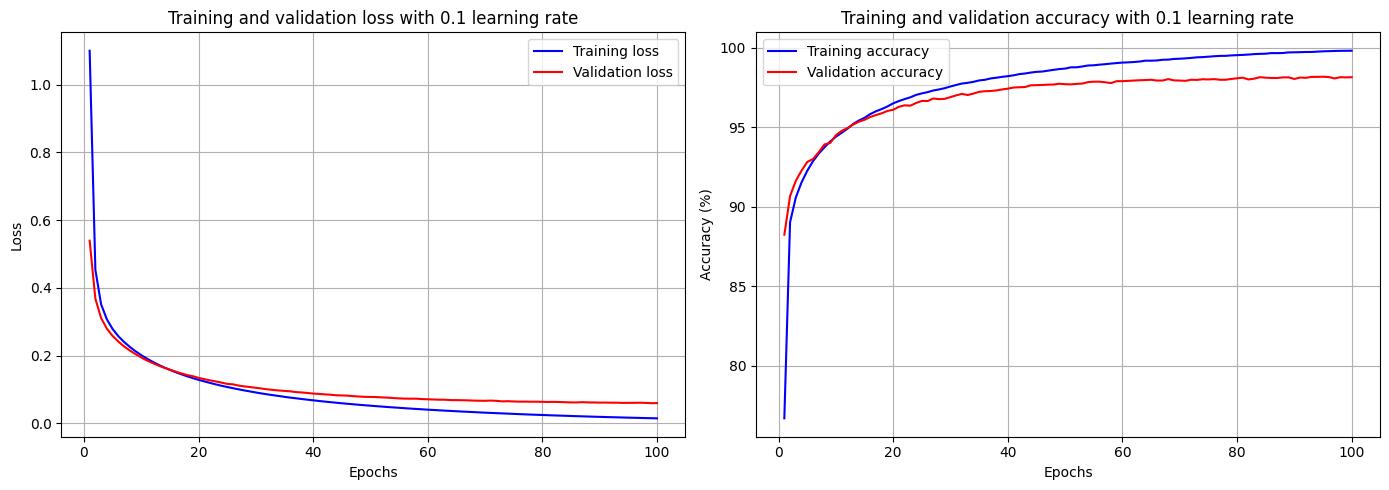

In [27]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 设置设备
device = "cpu"

# 定义模型
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)
    return model, loss_fn, optimizer

# 准备数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 训练参数
epochs = 100
model, loss_fn, optimizer = get_model()

# 记录指标
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# 训练循环
for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.view(-1, 28 * 28).to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        train_correct += pred.eq(target.view_as(pred)).sum().item()
        train_total += target.size(0)
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    
    # 验证阶段
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            data = data.view(-1, 28 * 28).to(device)
            target = target.to(device)
            
            output = model(data)
            loss = loss_fn(output, target)
            
            val_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
            val_total += target.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
    print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    print('-' * 50)

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失图
ax1.plot(range(1, epochs+1), train_losses, 'b-', label='Training loss')
ax1.plot(range(1, epochs+1), val_losses, 'r-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss with 0.1 learning rate')
ax1.legend()
ax1.grid(True)

# 准确率图
ax2.plot(range(1, epochs+1), train_accuracies, 'b-', label='Training accuracy')
ax2.plot(range(1, epochs+1), val_accuracies, 'r-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and validation accuracy with 0.1 learning rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

从上图中，我们可以看到模型的学习速度相对而言慢了很多，与学习率为 0.001 时相比，需要 100 个 epoch 模型才能达到约 89% 的准确率，而学习率为 0.001 时只需要 8 个 epoch。此外，与较大学习率相比，当学习率较低时，训练和验证损失之间的差距要小得多。这是因为，当学习率较低时，权重更新幅度也要低得多，训练和验证损失之间的差距并不会迅速扩大。

我们已经了解了学习率对训练和验证数据集准确率的影响。在下一节中，我们将了解不同学习率的权重值在各层之间的分布变化。

#### 3.1.4 不同学习率的模型参数分布  
我们已经了解到，在较高学习率时( 0.1)，模型被无法正确训练(模型欠拟合)在学习率中等( 0.001 )或低 (0.00001 )时可以得到较高的准确率。中等学习率能够快速过拟合，而较低学习率需要更长的时间才能达到与中等学习率模型相近的准确率。在本节中，我们将了解参数分布如何衡量模型过拟合和欠拟合。

在我们使用的简单模型中有四个参数组：  
- 连接输入层和隐藏层的层权重
- 隐藏层中的偏置值
- 连接隐藏层和输出层的层权重
- 输出层的偏置值  

![参数可视化](../Images/9.1.png)

在上图中，我们可以看到：  
- 当学习率较高时，与中低学习率相比，参数的分布范围大得多
- 当参数分布范围较大时，就会发生过拟合

### 3.2 学习率对未缩放数据集的影响  
在本节中，我们定义数据集类时使用未缩放的数据集：

In [28]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

使用不同学习率训练模型，准确率和损失随 epoch 的变化如下：

![changes](../Images/9.2.png)

在上图中可以看到，当数据集并未缩放时，学习率为 0.1 时无法训练出准确的模型，而学习率为 0.001 时准确率也会下降，当学习率非常小时( 0.00001 )时，模型同样能够学习得到较优性能，但出现了过拟合问题。我们可以通过查看网络各层的权重参数分布来理解这种情况发生的原因：

![参数分布](../Images/9.3.png)

可以看到，与较高的学习率相比，当模型学习率较低时，权重的范围相对小得多。在未缩放数据集上学习率为 0.00001 等价于在缩放数据集上学习率为 0.001 时的模型性能，这时学习率较低时权重可以以较小幅度进行修改，因为在这种情况下 梯度x学习率 是一个非常小的值。通常，学习率过低会导致训练模型需要较长时间，而学习率过高会导致模型训练变得不稳定。

## 小结  
学习率的优化是神经网络训练中不可或缺的一环，合理地选择学习率及采用适当的调整策略，能够帮助提升模型的训练效果。本节中，我们介绍了学习率影响模型训练的原理，并通过实战展示了不同学习率对模型性能的影响。